<a href="https://colab.research.google.com/github/aydanali/ECON3916-Stats-and-ML/blob/main/Lab10/Lab10_StatsML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas_datareader
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


In [3]:
df

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0
...,...,...,...,...,...
2023-09-01,307.276,3.7,5.33,101.0211,20771.8
2023-10-01,307.696,3.9,5.33,100.4689,20737.1
2023-11-01,308.148,3.7,5.33,100.8639,20743.4


In [ ]:
fig, axes = plt.subplot(1, 2)

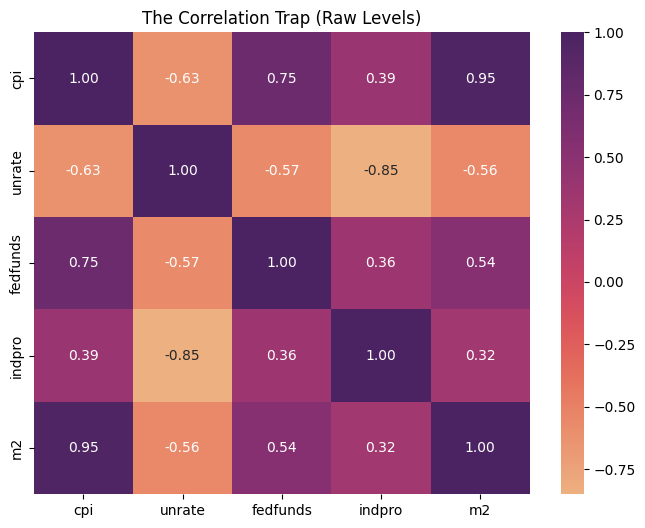

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='flare', fmt='.2f')
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [18]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


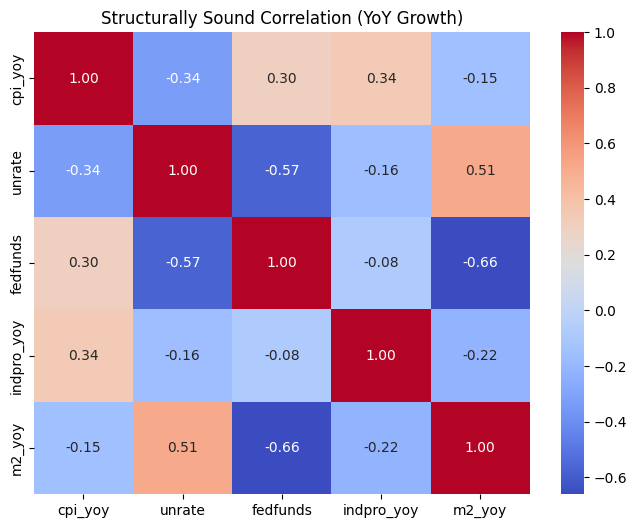

In [19]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

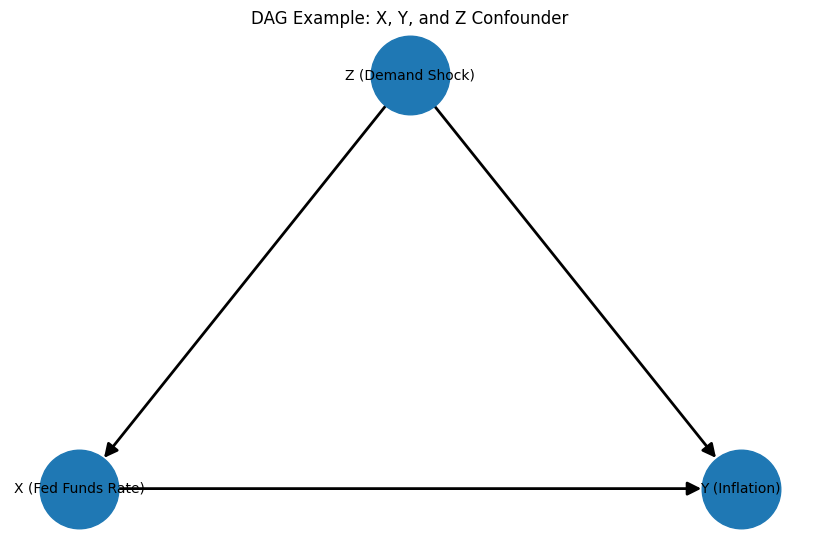

In [20]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

In [22]:
"""
FRED Macroeconomic Correlation Heatmap Dashboard
=================================================
Interactive Plotly dashboard featuring a dropdown toggle between:
  - Raw levels correlation matrix
  - YoY growth rates correlation matrix

Uses RdBu color scale with annotated correlation values.
"""

import numpy as np
import pandas as pd
import plotly.graph_objects as go


# ─────────────────────────────────────────────
# 1.  SIMULATE / LOAD YOUR FRED DATA
# ─────────────────────────────────────────────
# Replace this block with your actual DataFrame if you already have it.
# Expected columns (raw levels):
#   cpi, unemployment, fed_funds, industrial_production, m2
np.random.seed(42)
n = 200  # monthly observations (~17 years)

# Simulate realistic cointegrated macro series
t = np.arange(n)
cpi        = 100 + 0.03 * t + np.cumsum(np.random.normal(0, 0.2, n))
m2         = 8000 + 50 * t + np.cumsum(np.random.normal(0, 80, n))
fed_funds  = np.clip(2 + 0.5 * np.sin(t / 30) + np.random.normal(0, 0.3, n), 0, 10)
unemp      = np.clip(5 - 0.01 * t + np.random.normal(0, 0.4, n), 3, 12)
indpro     = 80 + 0.1 * t + np.cumsum(np.random.normal(0, 0.5, n))

df = pd.DataFrame({
    "CPI":                   cpi,
    "Unemployment":          unemp,
    "Fed Funds":             fed_funds,
    "Industrial Production": indpro,
    "M2":                    m2,
})


# ─────────────────────────────────────────────
# 2.  COMPUTE YoY GROWTH RATES
#     YoY % change = (x_t / x_{t-12} - 1) * 100
# ─────────────────────────────────────────────
df_yoy = df.pct_change(periods=12) * 100  # 12-month rolling % change
df_yoy.dropna(inplace=True)               # drop the first 12 NaN rows


# ─────────────────────────────────────────────
# 3.  CORRELATION MATRICES
# ─────────────────────────────────────────────
corr_levels = df.corr()         # raw levels  → often spuriously high
corr_yoy    = df_yoy.corr()     # YoY rates   → stationary, more reliable

labels = corr_levels.columns.tolist()


# ─────────────────────────────────────────────
# 4.  HELPER: build annotation list for a matrix
# ─────────────────────────────────────────────
def make_annotations(matrix: pd.DataFrame) -> list[dict]:
    """
    Returns a list of Plotly annotation dicts that overlay the
    rounded correlation value on every cell of the heatmap.
    Font color flips to white on strongly saturated cells for contrast.
    """
    annotations = []
    vals = matrix.values
    for i, row_label in enumerate(matrix.index):
        for j, col_label in enumerate(matrix.columns):
            val = vals[i, j]
            # Use white text when the cell is strongly red or blue
            font_color = "white" if abs(val) > 0.6 else "#1a1a2e"
            annotations.append(dict(
                x=col_label,
                y=row_label,
                text=f"{val:.2f}",
                showarrow=False,
                font=dict(size=12, color=font_color, family="IBM Plex Mono"),
                xref="x", yref="y",
            ))
    return annotations


# ─────────────────────────────────────────────
# 5.  BUILD THE FIGURE WITH TWO HEATMAP TRACES
#     Only one trace is visible at a time;
#     the dropdown swaps visibility.
# ─────────────────────────────────────────────

# Shared heatmap kwargs
heatmap_kwargs = dict(
    x=labels,
    y=labels,
    colorscale="RdBu",
    zmid=0,          # anchor zero at the midpoint of the diverging scale
    zmin=-1,
    zmax=1,
    colorbar=dict(
        title=dict(text="Pearson r", font=dict(size=13)),
        thickness=18,
        len=0.85,
        tickfont=dict(family="IBM Plex Mono", size=11),
    ),
    showscale=True,
)

# Trace 0 – Raw Levels
trace_levels = go.Heatmap(
    z=corr_levels.values,
    name="Raw Levels",
    visible=True,    # shown by default
    **heatmap_kwargs,
)

# Trace 1 – YoY Growth Rates
trace_yoy = go.Heatmap(
    z=corr_yoy.values,
    name="YoY Growth Rates",
    visible=False,   # hidden until user selects it
    **heatmap_kwargs,
)

fig = go.Figure(data=[trace_levels, trace_yoy])


# ─────────────────────────────────────────────
# 6.  DROPDOWN via `updatemenus`
#
#  HOW IT WORKS (architecture):
#  ────────────────────────────
#  Plotly's `updatemenus` component stores a list of *button* objects.
#  Each button carries an `args` payload—a list of [patch_dict, layout_patch].
#  When clicked, Plotly merges those patches into the live figure *in the
#  browser* (no round-trip to Python/server needed).
#
#  The `method` field controls HOW the patch is applied:
#    • "restyle"  → updates trace properties (data layer)
#    • "relayout" → updates layout properties (axes, title, annotations…)
#    • "update"   → shorthand for both restyle + relayout simultaneously
#    • "animate"  → triggers a Plotly animation frame
#
#  Here we use "update" because we need to:
#    (a) restyle  → flip trace visibility   [args[0]]
#    (b) relayout → swap annotation overlay [args[1]]
#
#  args[0] = {"visible": [True, False]}  means trace-0 on, trace-1 off.
#  args[1] = {"annotations": [...]}      replaces ALL layout annotations.
#
#  The result: clicking a button is a pure client-side JSON patch—
#  snappy, offline-capable, and zero server dependency.
# ─────────────────────────────────────────────

annotations_levels = make_annotations(corr_levels)
annotations_yoy    = make_annotations(corr_yoy)

dropdown_buttons = [
    dict(
        label="📊  Raw Levels",
        method="update",                       # restyle + relayout
        args=[
            {"visible": [True, False]},        # show trace 0, hide trace 1
            {
                "title.text": (
                    "<b>Correlation Matrix — Raw Levels</b><br>"
                    "<sup>Spurious correlations likely due to shared trends</sup>"
                ),
                "annotations": annotations_levels,
            },
        ],
    ),
    dict(
        label="📈  YoY Growth Rates",
        method="update",
        args=[
            {"visible": [False, True]},        # hide trace 0, show trace 1
            {
                "title.text": (
                    "<b>Correlation Matrix — YoY Growth Rates</b><br>"
                    "<sup>Stationarity-corrected; spurious correlations reduced</sup>"
                ),
                "annotations": annotations_yoy,
            },
        ],
    ),
]

fig.update_layout(
    # ── Dropdown placement ──────────────────────────────────────────────
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        x=0.01,
        xanchor="left",
        y=1.15,
        yanchor="top",
        bgcolor="#0f3460",
        bordercolor="#e94560",
        borderwidth=2,
        font=dict(color="white", size=13, family="IBM Plex Mono"),
        buttons=dropdown_buttons,
        active=0,              # first button selected on load
    )],

    # ── Default title (matches active=0 = Raw Levels) ───────────────────
    title=dict(
        text=(
            "<b>Correlation Matrix — Raw Levels</b><br>"
            "<sup>Spurious correlations likely due to shared trends</sup>"
        ),
        font=dict(size=18, color="#e0e0e0", family="IBM Plex Mono"),
        x=0.5, xanchor="center",
        y=0.97,
    ),

    # ── Default annotations (raw levels) ────────────────────────────────
    annotations=annotations_levels,

    # ── Axes ────────────────────────────────────────────────────────────
    xaxis=dict(
        tickangle=-35,
        tickfont=dict(size=12, family="IBM Plex Mono", color="#c9d1d9"),
        showgrid=False,
        linecolor="#30363d",
    ),
    yaxis=dict(
        tickfont=dict(size=12, family="IBM Plex Mono", color="#c9d1d9"),
        showgrid=False,
        linecolor="#30363d",
        autorange="reversed",   # top-left = [0,0] convention
    ),

    # ── Theme ────────────────────────────────────────────────────────────
    plot_bgcolor="#0d1117",
    paper_bgcolor="#0d1117",
    font=dict(color="#c9d1d9"),
    width=780,
    height=720,
    margin=dict(l=130, r=60, t=120, b=110),
)


# ─────────────────────────────────────────────
# 7.  EXPORT
# ─────────────────────────────────────────────
output_path = "fred_correlation_heatmap.html"
fig.write_html(
    output_path,
    include_plotlyjs="cdn",   # loads Plotly.js from CDN — keeps file small
    full_html=True,
)
print(f"Dashboard saved → {output_path}")

# Uncomment to open in browser immediately:
fig.show()

Dashboard saved → fred_correlation_heatmap.html
